## Step 1: Import the necessary libraries:


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
from utils import *

## Step 2: Define the environment:


In [32]:
devices_path = "./resources/scattered_devices.csv"
tasks_path = "./resources/scattered_tasks.csv"
result_path = "./results/test_result.csv"

### DEVICES


In [33]:
import ast

def read_devices():
    devices = pd.read_csv(devices_path)

    devices["voltages_frequencies"] = devices["voltages_frequencies"].apply(lambda x: ast.literal_eval(x))
    devices["capacitance"] = devices["capacitance"].apply(
        lambda x: ast.literal_eval(x)
    )
    devices["occupied_cores"] = devices["occupied_cores"].apply(
        lambda x: ast.literal_eval(x)
    )
    devices["powerIdle"] = devices["powerIdle"].apply(
        lambda x: ast.literal_eval(x)
    )
    devices["acceptableTasks"] = devices["acceptableTasks"].apply(
        lambda x: ast.literal_eval(x)
    )
    devices = devices.drop(["Unnamed: 0"],axis=1)
    return devices

In [34]:
def plot_historie(rSetup, init_punish, punish, lossHistory, avg_time_history, avg_energy_history, avg_fail_history, iot_usage, mec_usage, cc_usage, path_history):
    fig, axs = plt.subplots(3, 2, figsize=(20, 15))  # Create a grid of 3x2 for plots

    plt.suptitle(f"Training History with setup {rSetup}, initial punish: {init_punish}, final punish: {punish}, mode: {2}", fontsize=16, fontweight='bold')

    # Plot for average loss history
    loss_values = [l.detach().numpy() if isinstance(l, torch.Tensor) else l for l in lossHistory]
    axs[0, 0].plot(loss_values, label='Average Loss', color='blue', marker='o')  # Add markers for clarity
    axs[0, 0].set_title('Average Loss History')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Plot for average time history
    time_values = np.array(avg_time_history)  # Ensure data is in numpy array
    axs[0, 1].plot(time_values, label='Average Time', color='red', marker='o')
    axs[0, 1].set_title('Average Time History')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Time')
    axs[0, 1].legend()
    axs[0, 1].grid(True)
    
    time_lower_bound = 0.00625
    time_middle_bound = 0.0267
    time_upper_bound = 1
    # axs[0, 1].axhline(y=time_lower_bound, color='blue', linestyle='--', label='Lower Bound (0.00625)')
    # axs[0, 1].axhline(y=time_middle_bound, color='green', linestyle='--', label='Middle Bound (0.0267)')
    # axs[0, 1].axhline(y=time_upper_bound, color='red', linestyle='--', label='Upper Bound (1)')
    axs[0, 1].legend()

    # Plot for average energy history
    energy_values = np.array(avg_energy_history)
    axs[1, 0].plot(energy_values, label='Average Energy', color='green', marker='o')
    axs[1, 0].set_title('Average Energy History')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Energy')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    energy_lower_bound = 0.0000405
    energy_middle_bound = 0.100746
    energy_upper_bound = 1.2
    # axs[1, 0].axhline(y=energy_lower_bound, color='blue', linestyle='--', label='Lower Bound (0.0000405)')
    # axs[1, 0].axhline(y=energy_middle_bound, color='green', linestyle='--', label='Middle Bound (0.100746)')
    # axs[1, 0].axhline(y=energy_upper_bound, color='red', linestyle='--', label='Upper Bound (1.2)')
    axs[1, 0].legend()

    # Plot for average fail history
    fail_values = np.array(avg_fail_history)
    axs[1, 1].plot(fail_values, label='Average Fail', color='purple', marker='o')
    axs[1, 1].set_title('Average Fail History')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Fail Count')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # Plot for devices usage history
    axs[2, 0].plot(iot_usage, label='IoT Usage', color='blue', marker='o')
    axs[2, 0].plot(mec_usage, label='MEC Usage', color='orange', marker='x')
    axs[2, 0].plot(cc_usage, label='Cloud Usage', color='green', marker='s')
    axs[2, 0].set_title('Devices Usage History')
    axs[2, 0].set_xlabel('Epochs')
    axs[2, 0].set_ylabel('Usage')
    axs[2, 0].legend()
    axs[2, 0].grid(True)

    # Heatmap for path history
    output_classes = ["LLL", "LLR", "LRL", "LRR", "RLL", "RLR", "RRL", "RRR"]
    # output_classes = ["L", "R"]
    path_counts = np.zeros((len(path_history), len(output_classes)))

    for epoch in range(len(path_history)):
        epoch_paths = path_history[epoch]

        for path in epoch_paths:
            path_index = output_classes.index(path)
            path_counts[epoch, path_index] += 1

    sns.heatmap(path_counts, cmap="YlGnBu", xticklabels=output_classes, ax=axs[2, 1])
    axs[2, 1].set_title(f'Path History Heatmap - All Epochs\n(r: {rSetup}, p: {init_punish}, m:)')
    axs[2, 1].set_xlabel('Output Classes')
    axs[2, 1].set_ylabel('Epochs')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"./results/Energy Figs/r{rSetup}_m")
    plt.show()


### Application


In [35]:
def read_tasks(regular=False):
    tasks = pd.read_csv(tasks_path)
    tasks = tasks.sample(frac=1)
    tasks = tasks.set_index("id")
    tasks_copy = tasks.copy()
    kinds = [1, 2, 3, 4]
    for kind in kinds:
        tasks_copy[f'kind{kind}'] = tasks_copy['kind'].isin([kind]).astype(int)
    tasks_copy = tasks_copy.drop(["kind","job","dependency","mobility","status"],axis=1)
    if regular :
        for column in tasks_copy.columns.values:
            tasks_copy[column] = (tasks_copy[column] - tasks_copy[column].min()) / (tasks_copy[column].max() - tasks_copy[column].min())
    return tasks, tasks_copy

## Step 4 : DDT


In [36]:
class DDT(nn.Module):
    def __init__(self, num_input, num_output, depth, max_depth, num_epoch, counter=0, exploration_rate=0):
        super(DDT, self).__init__()
        self.depth = depth
        self.max_depth = max_depth
        self.epsilon = 1e-5
        
        self.exp_mid_bound = num_epoch * self.epsilon
        self.exploration_rate = self.exp_mid_bound + (self.exp_mid_bound / 2)
        self.exp_threshold = self.exp_mid_bound - (self.exp_mid_bound / 2)
        self.shouldExplore = 0
        
        self.counter = counter 
        if depth != max_depth:
            self.weights = nn.Parameter(torch.empty(
                num_input).normal_(mean=0, std=0.1))
            self.bias = nn.Parameter(torch.zeros(1))
        if depth == max_depth:
            self.prob_dist = nn.Parameter(torch.zeros(num_output))
        if depth < max_depth:
            self.left = DDT(num_input, num_output, depth + 1, max_depth,self.counter, self.exploration_rate)
            self.right = DDT(num_input, num_output, depth + 1, max_depth,self.counter, self.exploration_rate)


    def forward(self, x, path=""):
        if self.depth == self.max_depth:
            return self.prob_dist, path
        val = torch.sigmoid(
            (torch.matmul(x, self.weights) + self.bias))
        a = np.random.random()
        a = float("{:.6f}".format(a))
        if a < self.exploration_rate and self.shouldExplore:
            self.counter += 1
            val = 1 - val
            self.exploration_rate -= self.epsilon
            if self.exploration_rate < self.exp_threshold:
                self.shouldExplore = 0

        if val >= 0.5:
            right_output, right_path = self.right(x, path + "R")
            return val * right_output, right_path
        else:
            left_output, left_path = self.left(x, path + "L")
            return (1 - val) * left_output, left_path

## Step 5: RL


In [37]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


class ValueNetwork(nn.Module):
    def __init__(self, input_size):
        super(ValueNetwork, self).__init__()
        self.input_size = input_size
        self.net = nn.Sequential(
            nn.Linear(self.input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x)


critic = ValueNetwork(8)
criterion = nn.MSELoss()
critic_optimizer = optim.Adam(critic.parameters(), lr=0.005)

In [38]:
class Environment:
    def __init__(self,num_epochs):
        self.rewardSetup = 1
        self.punish = 0
        self.punish_epsilon = 0
        self.alpha = 1
        self.beta = 1
        
        self.tasks,self.tasks_copy = read_tasks(regular= True)
        self.devices = read_devices()
        self.feature_size = len(self.tasks_copy.columns)
        self.num_actions = len(self.devices)
        self.agent = DDT(self.feature_size, self.num_actions,depth=0, max_depth=3, num_epoch=num_epochs)
        self.optimizer = optim.Adam(self.agent.parameters(), lr=0.005)

        self.avg_time_history = np.array([])
        self.avg_energy_history = np.array([])
        self.avg_fail_history = np.array([0,0,0])
        self.avg_loss_history = np.array([])
        self.avg_reward_history = np.array([])

        self.total_iot_usage_history = []
        self.total_mec_usage_history = []
        self.total_cc_usage_history = []
        self.path_history = []

        self.old_log_probs = {i: None for i in range(self.num_actions)}  # TODO: Store log probabilities for all actions as a dictionary
        
        self.initial_exp_rate = self.agent.exploration_rate
        self.initial_punish = self.punish

    def execute_action(self, state, action):
        self.tasks_copy = self.tasks_copy.iloc[1:]
        self.tasks = self.tasks.iloc[1:]
        device = self.devices.iloc[action]        
        
        taskFail, safeFail = checkIfSuitable(state, device)
        punishment = self.punish * (taskFail + safeFail)
        if not (taskFail or safeFail):
            for coreIndex in range(len(device["occupied_cores"])):
                if device["occupied_cores"][coreIndex] == 0:
                    total_t, total_e  = calc_total(device, state, coreIndex,0)
                    reward = getSetup(total_e, total_t, self.rewardSetup,self.alpha, self.beta)
                    return (reward,total_t,total_e,0,0)      
        return (punishment,0,0, taskFail,safeFail)


    def train(self, num_epoch, num_episodes, epsilon=0.2):  # TODO: Added epsilon parameter for PPO clipping
        for i in range(num_epoch):

            total_time_epoch = 0
            total_energy_epoch = 0
            total_reward_epoch = 0
            total_loss_epoch = 0
            total_fail_epoch = np.array([0, 0, 0])
            
            total_iot_usage = 0
            total_mec_usage = 0
            total_cc_usage = 0

            self.punish += self.punish_epsilon

            temp_paths = []
            
            if i == (num_epoch // 2):
                print("half epochs punish: ", self.punish)
            for j in range(num_episodes):
                state = self.tasks.iloc[0]
                temp_state = self.tasks_copy.iloc[0]
                x = torch.tensor(np.array(temp_state.values, dtype=np.float32)).unsqueeze(0)
                
                output, path = self.agent(x)
                temp_paths.append(path)
                if j == num_episodes - 1:
                    self.path_history.append(temp_paths)

                # Compute current action probabilities and select action
                action_probabilities = torch.softmax(output, dim=0)
                action_index = torch.multinomial(action_probabilities, 1).item()  # TODO: Using torch.multinomial for action selection
                # action_index = torch.argmax(action_probabilities, dim=0).item()
                # Calculate log probabilities for all action indexes
                log_probs = torch.log10(action_probabilities)  # TODO: Calculate log probabilities for all actions

                reward, t, e, taskFail, safeFail = self.execute_action(state, action_index)

                next_state = torch.tensor(np.array(self.tasks_copy.iloc[0].values, dtype=np.float32)).unsqueeze(0)

                value = critic(x)
                next_value = critic(next_state)

                # Compute the target and advantage
                target = reward + 0.95 * next_value.item()
                target = torch.tensor([target], dtype=torch.float32)
                advantage = target - value

                # Retrieve the old log probability for the selected action, or initialize it
                old_log_prob = self.old_log_probs.get(action_index)

                if old_log_prob is None:
                    old_log_prob = log_probs[action_index].detach()  # Initialize with the current log_prob if not already stored
                # print(log_probs[action_index])
                # print(old_log_prob)
                # Calculate the ratio for PPO
                ratio = torch.exp(log_probs[action_index] - old_log_prob)  # TODO: Compute the probability ratio for PPO

                 # After PPO update, update log probabilities for all actions
                # for index in range(self.num_actions):
                #     self.old_log_probs[index] = log_probs[index].detach()  # : Now update the old_log_probs after the optimization step
                self.old_log_probs[action_index] = log_probs[action_index].detach()  # TODO: Update only the selected action's log_prob    
        
                # Clipped objective
                surr1 = ratio * advantage  # TODO: Standard surrogate objective term
                surr2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantage  # TODO: Clipped surrogate objective term
                actor_loss = -torch.min(surr1, surr2).mean()  # TODO: Use the minimum of the two objectives

                # Critic loss
                critic_loss = criterion(value, target)

                # Update Actor and Critic networks
                self.optimizer.zero_grad()
                actor_loss.backward(retain_graph=True)  # TODO: Update the actor with the PPO loss
                self.optimizer.step()

                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

                total_reward_epoch += reward
                total_loss_epoch += actor_loss.item() + critic_loss.item()  # TODO: Accumulate PPO actor loss
                total_time_epoch += t
                total_energy_epoch += e
                fails = np.array([taskFail + safeFail, taskFail, safeFail])
                total_fail_epoch += fails
                if self.devices.iloc[action_index]['id'].startswith("iot"):
                    total_iot_usage += 1
                if self.devices.iloc[action_index]['id'].startswith("mec"):
                    total_mec_usage += 1
                if self.devices.iloc[action_index]['id'].startswith("cloud"):
                    total_cc_usage += 1

            # Update averages and histories
            avg_time = total_time_epoch / num_episodes
            avg_energy = total_energy_epoch / num_episodes
            avg_reward = total_reward_epoch / num_episodes
            avg_loss = total_loss_epoch / num_episodes
            avg_fail = [elem / num_episodes for elem in total_fail_epoch]

            self.avg_loss_history = np.append(self.avg_loss_history, avg_loss)
            self.avg_reward_history = np.append(self.avg_reward_history, avg_reward)
            self.avg_time_history = np.append(self.avg_time_history, avg_time)
            self.avg_energy_history = np.append(self.avg_energy_history, avg_energy)
            self.avg_fail_history = np.vstack([self.avg_fail_history, avg_fail])

            self.total_iot_usage_history.append(total_iot_usage)
            self.total_mec_usage_history.append(total_mec_usage)
            self.total_cc_usage_history.append(total_cc_usage)

        # Save results and plot
        save_results(result_path, self.rewardSetup, self.initial_punish, self.avg_loss_history, self.avg_fail_history,
                    self.avg_time_history, self.avg_energy_history, self.avg_reward_history, num_epoch)

        plot_historie(self.rewardSetup, self.initial_punish, self.punish,
                         self.avg_loss_history, self.avg_time_history,
                          self.avg_energy_history,
                          self.avg_fail_history[:, 0],
                          self.total_iot_usage_history,
                          self.total_mec_usage_history,
                          self.total_cc_usage_history,
                            self.path_history)

In [39]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from collections import Counter

# Generate synthetic data
X, _ = make_blobs(n_samples=100, centers=5, cluster_std=0.6, random_state=42)

# Number of desired clusters
n_clusters = 5
n_samples = X.shape[0]
target_cluster_size = n_samples // n_clusters

# Perform initial K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
initial_labels = kmeans.fit_predict(X)

# Balancing step: reassign points to balance clusters
def balance_clusters(X, initial_labels, target_cluster_size):
    # Calculate initial cluster sizes
    cluster_sizes = Counter(initial_labels)

    # Initialize balanced labels
    balanced_labels = np.array(initial_labels)

    # Reassign points from larger clusters to smaller clusters
    for cluster in range(n_clusters):
        while cluster_sizes[cluster] > target_cluster_size:
            # Find points in this cluster
            points_in_cluster = np.where(balanced_labels == cluster)[0]

            # Choose a random point to reassign
            point_to_reassign = np.random.choice(points_in_cluster)

            # Find a smaller cluster to reassign this point
            for target_cluster in range(n_clusters):
                if cluster_sizes[target_cluster] < target_cluster_size:
                    balanced_labels[point_to_reassign] = target_cluster
                    cluster_sizes[cluster] -= 1
                    cluster_sizes[target_cluster] += 1
                    break

    return balanced_labels


/Users/aminsoltani/anaconda3/envs/ROV/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


punish epsilon:  0


/Users/aminsoltani/anaconda3/envs/ROV/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


half epochs punish:  -10
sdadsad


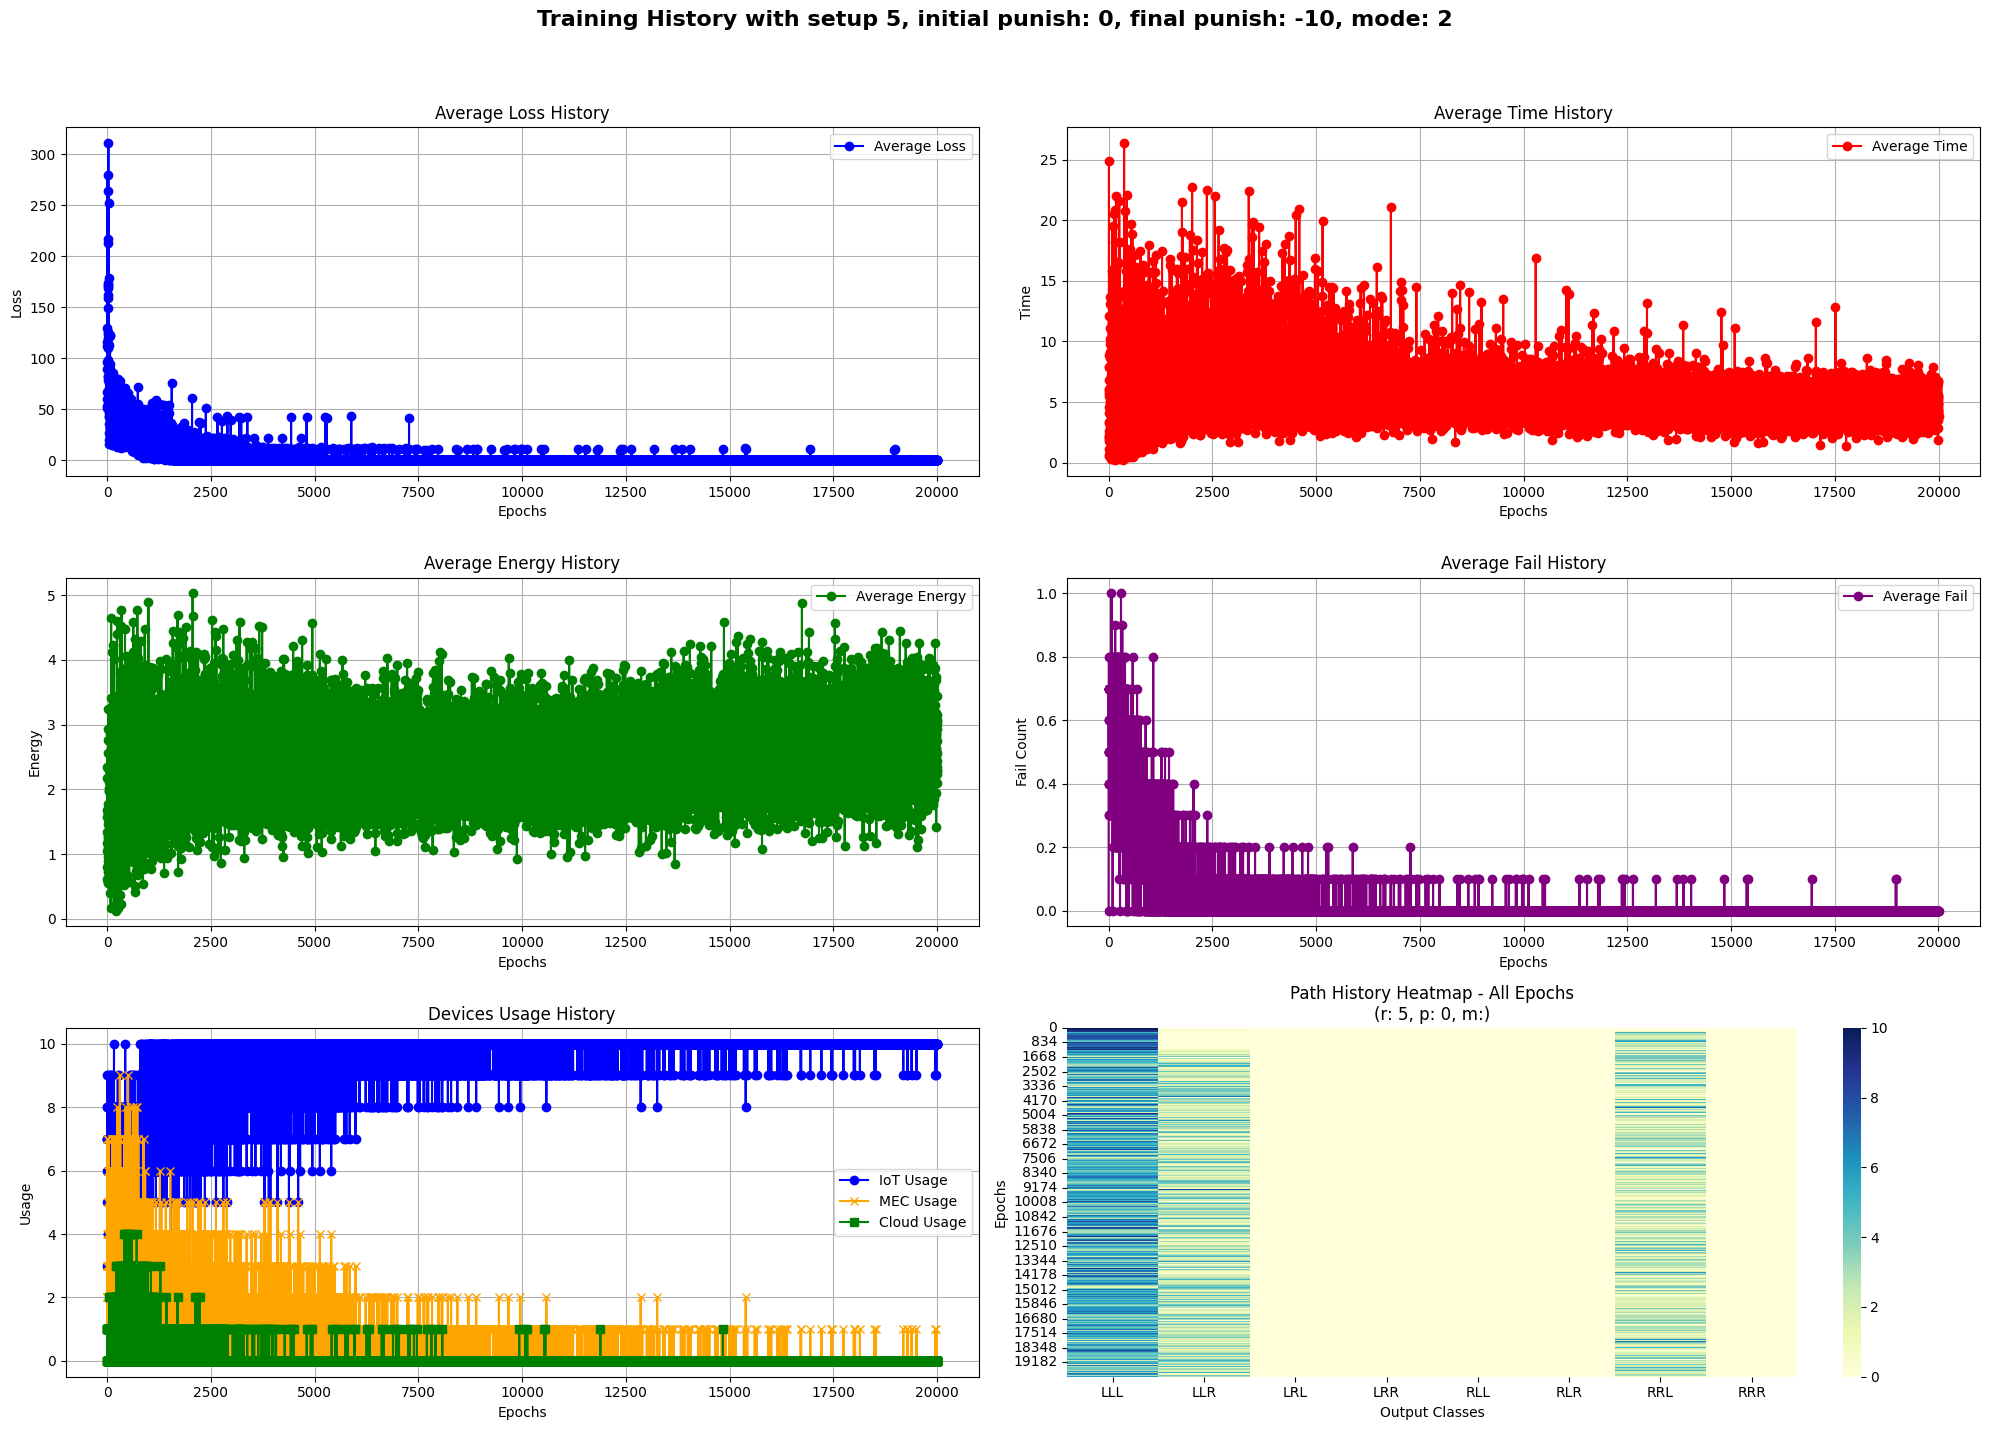

punish epsilon:  0


/Users/aminsoltani/anaconda3/envs/ROV/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


half epochs punish:  -10
sdadsad


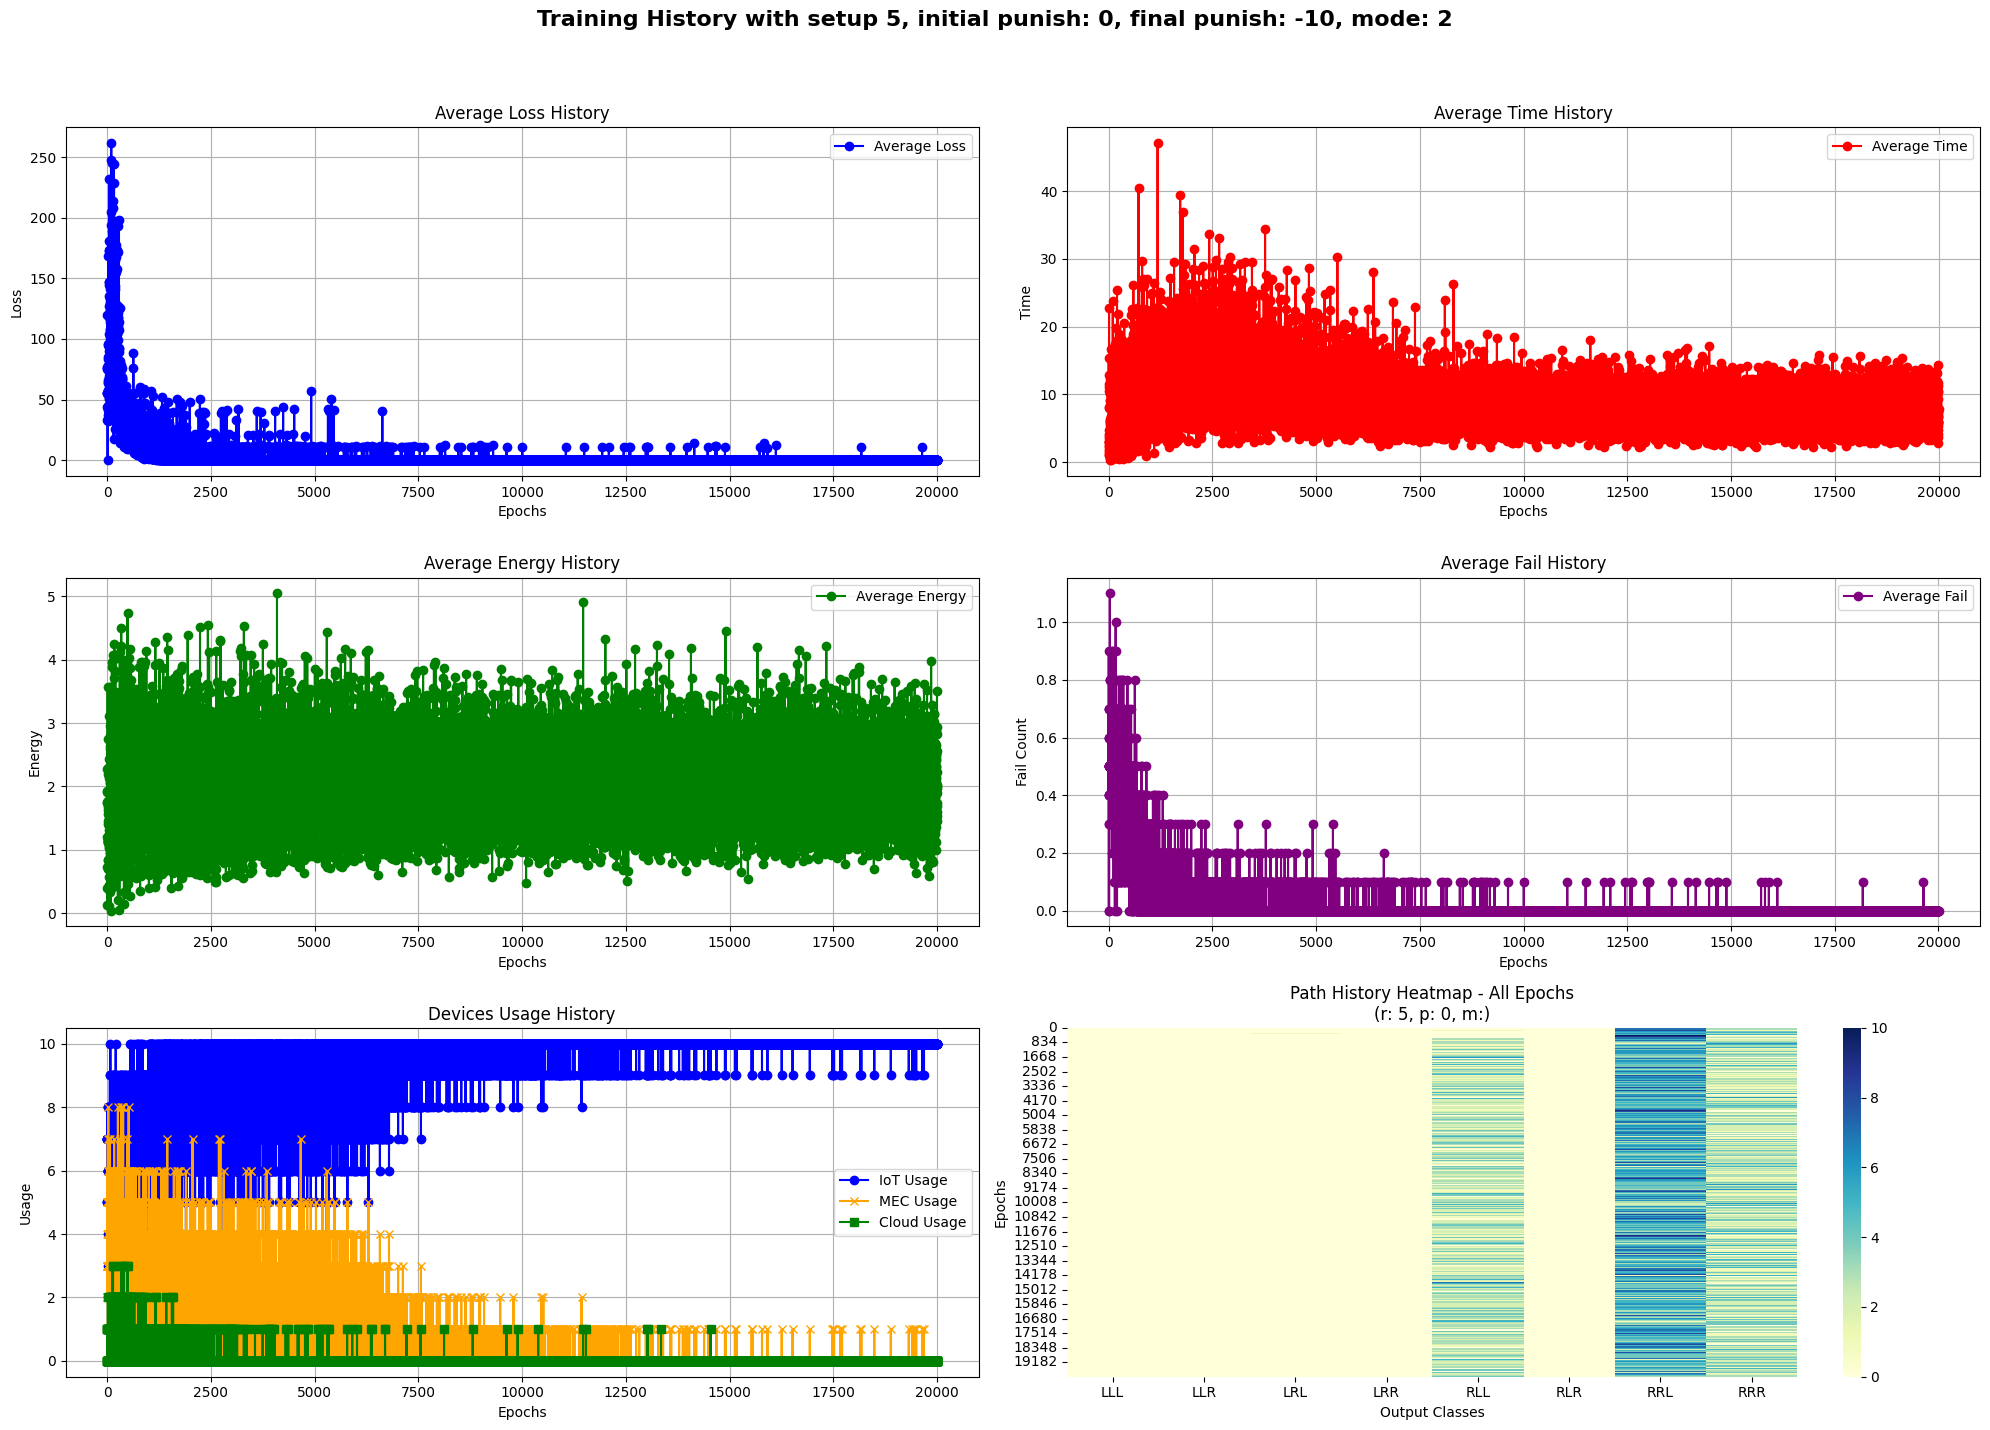

punish epsilon:  0


/Users/aminsoltani/anaconda3/envs/ROV/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


half epochs punish:  -10
sdadsad


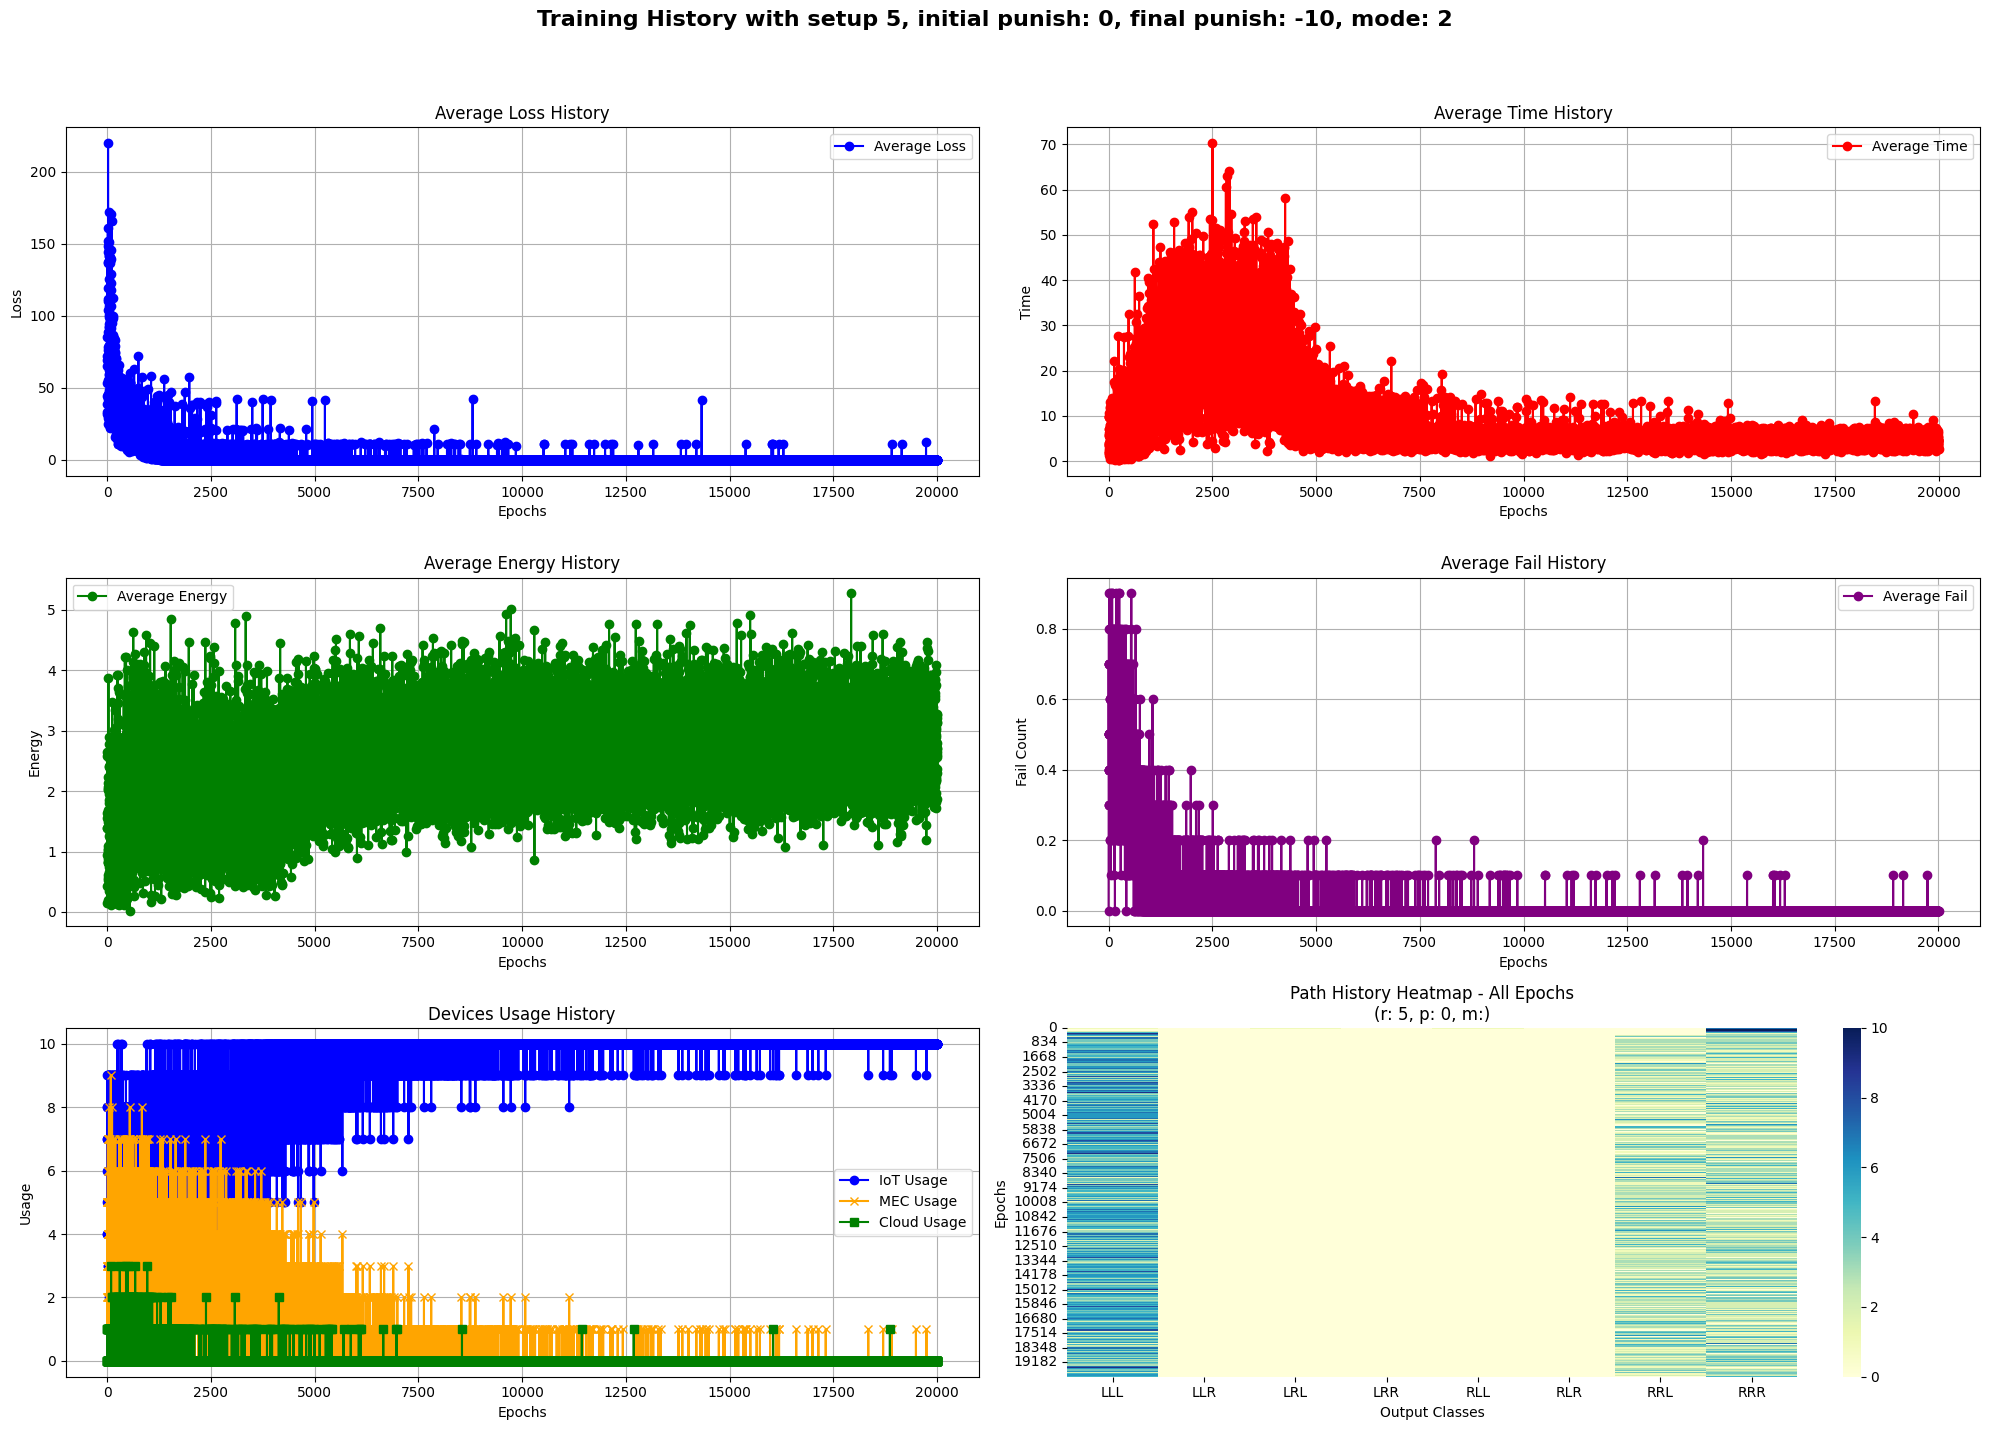

punish epsilon:  0


/Users/aminsoltani/anaconda3/envs/ROV/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


half epochs punish:  -10
sdadsad


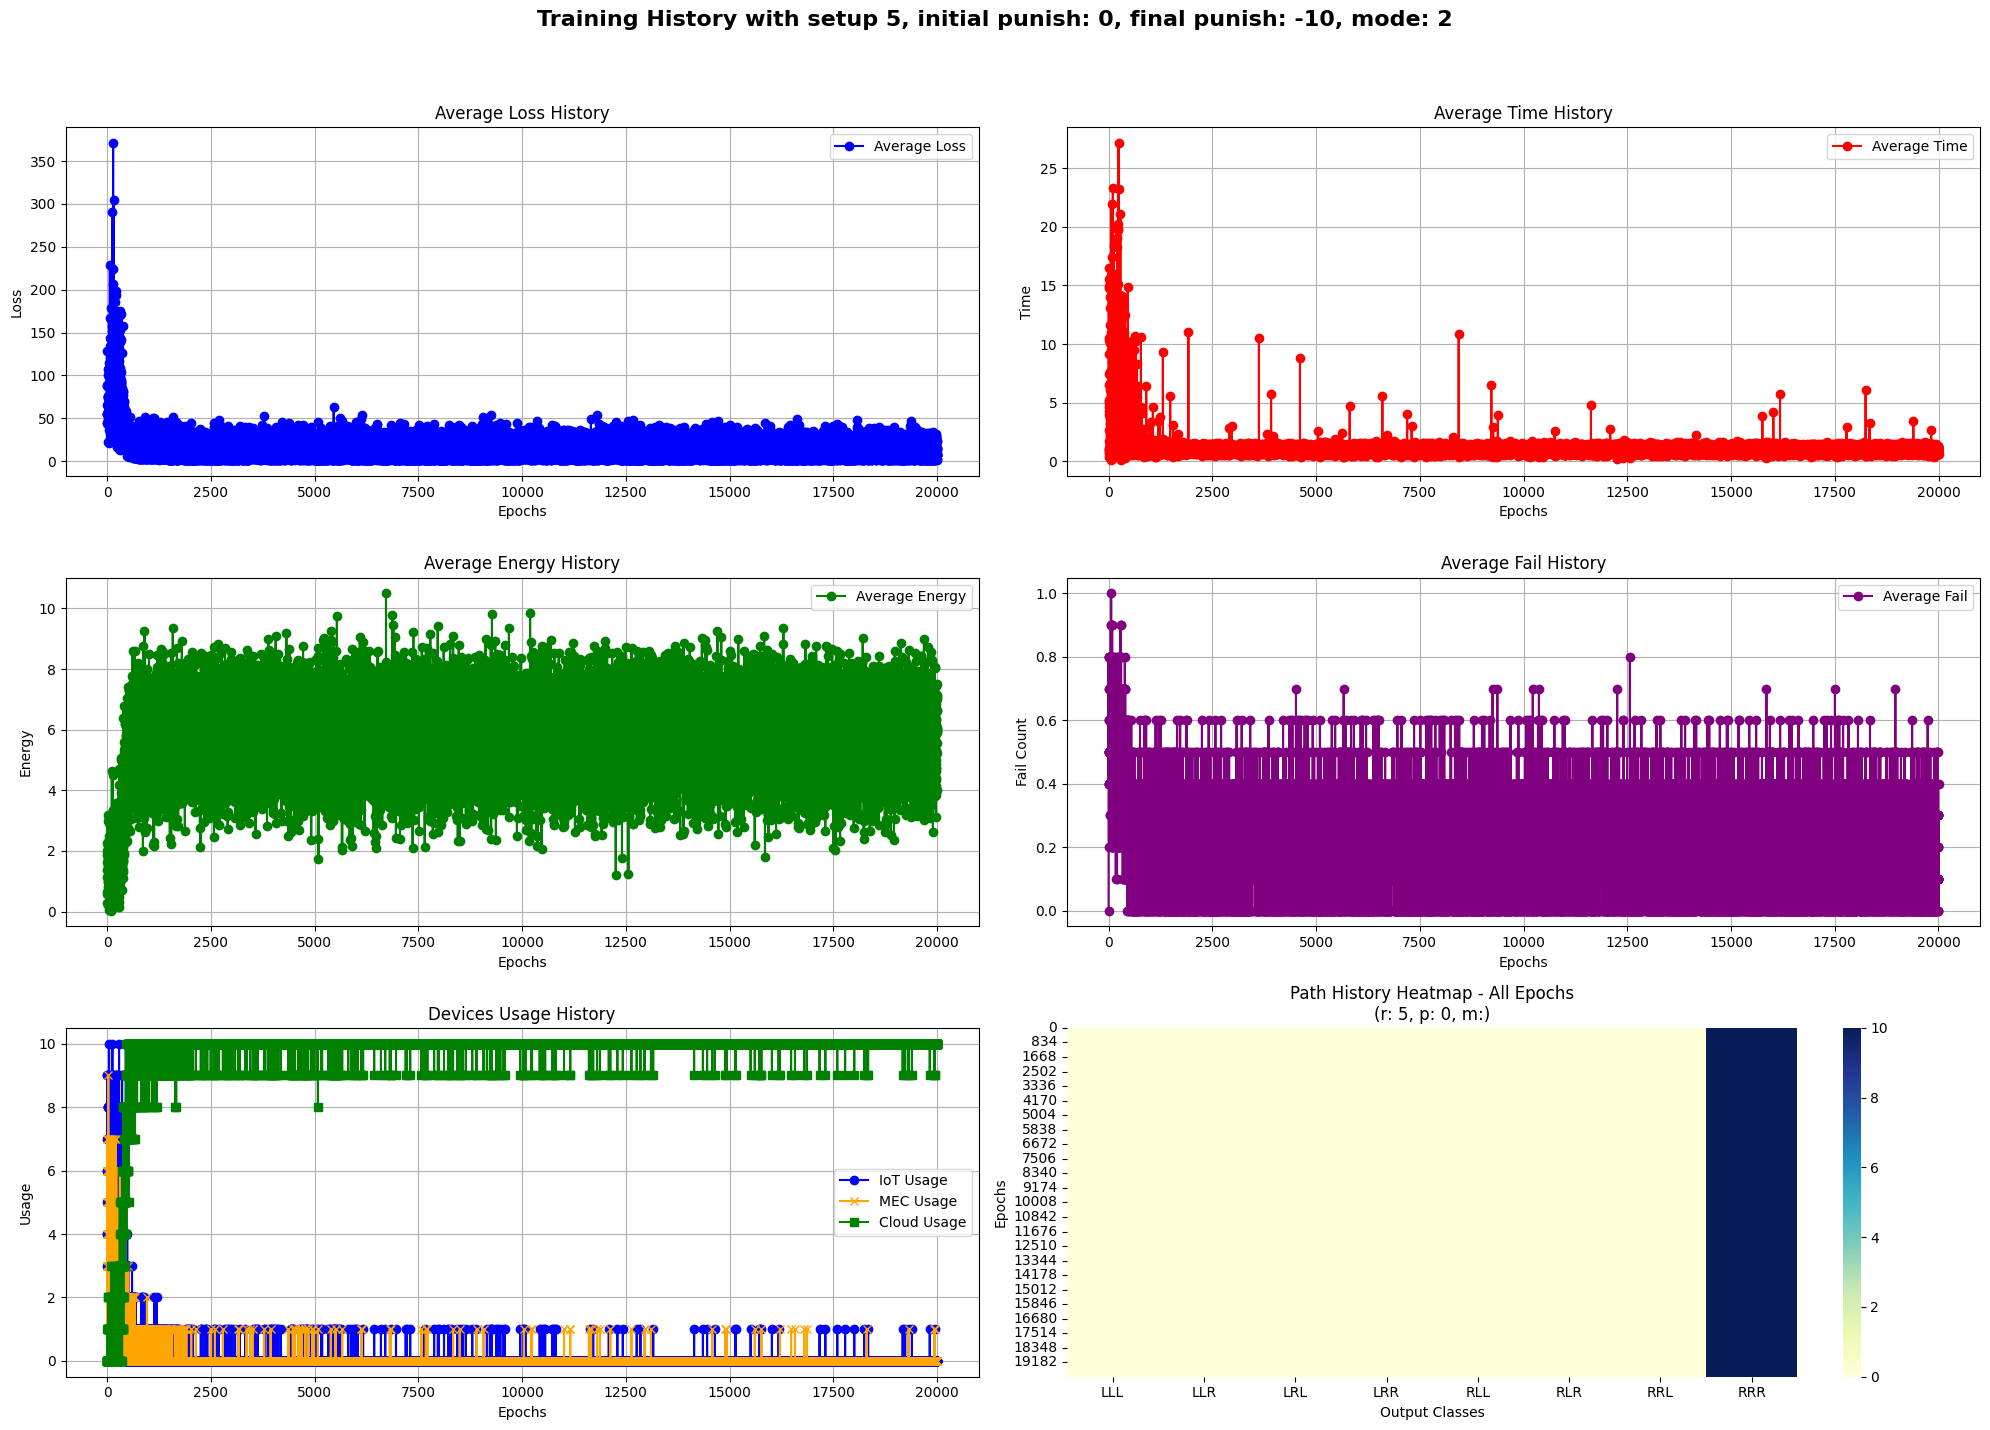

punish epsilon:  0


/Users/aminsoltani/anaconda3/envs/ROV/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


half epochs punish:  -10
sdadsad


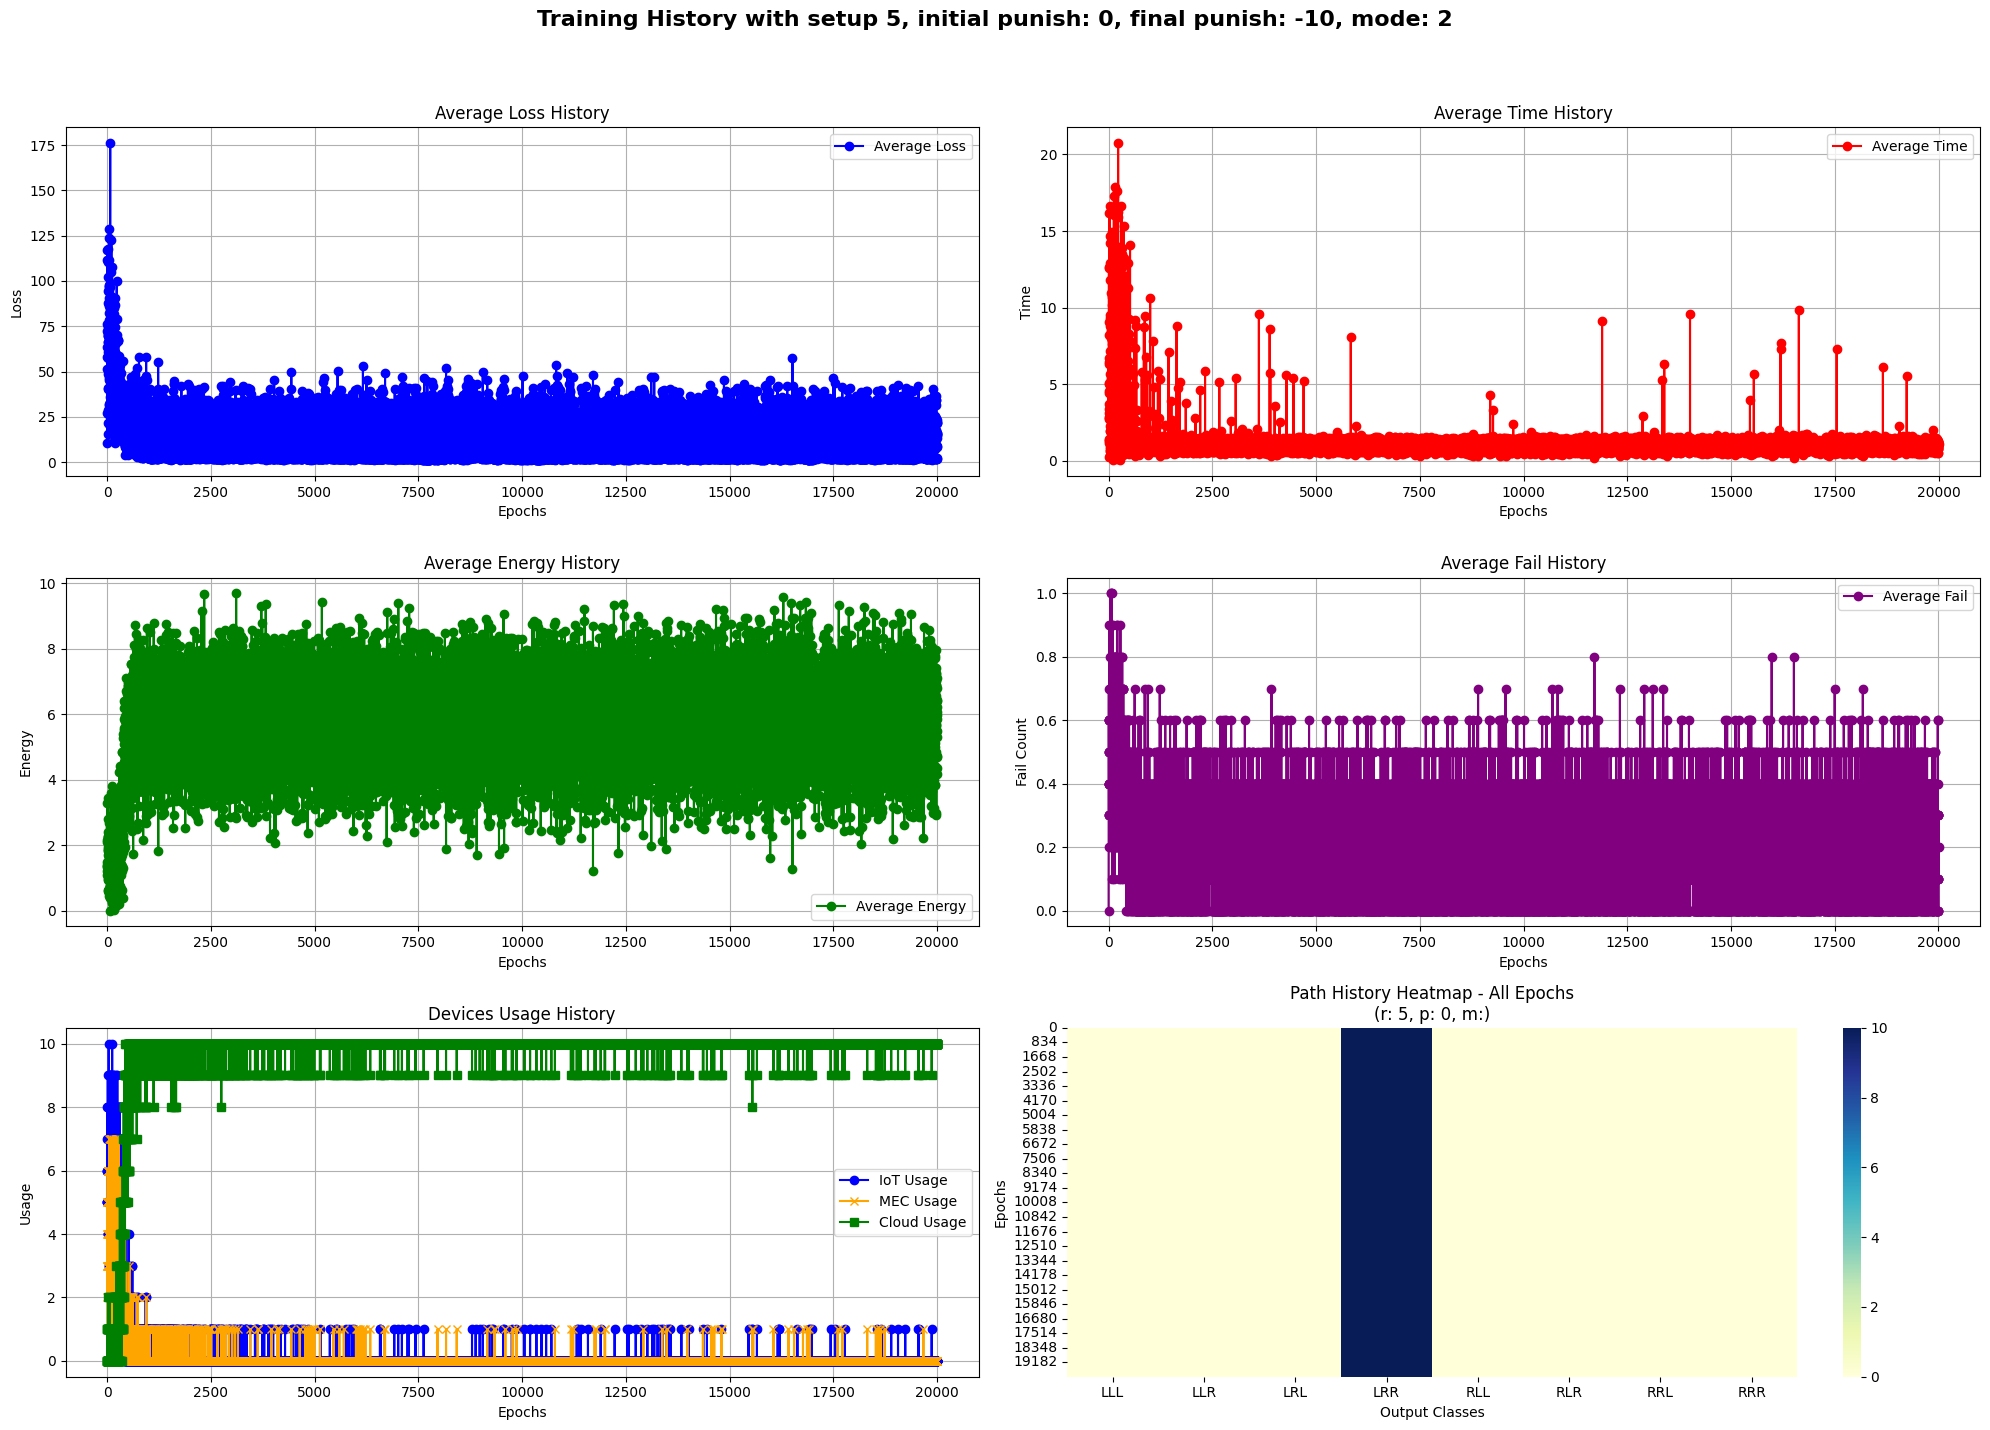

completed


In [40]:

def train_test(n):
    rpSetup_list = { 5: [-10]}

    for i in range(n):
        for reward, punishments in rpSetup_list.items():
            for punish in punishments: 
                num_epochs = 20001
                num_episodes = 10
                env = Environment(num_epochs=num_epochs)
                env.rewardSetup = reward
                env.punish = punish
                env.punish_epsilon = 0
                # env.punish_epsilon = -(punish - (punish * 10)) / (num_epochs / 2)
                print("punish epsilon: ", env.punish_epsilon)
                
                tree = env.agent
                env.train(num_epochs, num_episodes)
    
train_test(5)   
print("completed")